Please execute the cessls in order (The workflow proposed is maintained here).

In [2]:
import uproot
import numpy as np


A sample extraction fromm the root file generated will be attached but below is the code to convert that into poiny cloud data format 

As    S ∈ (xi​,yi​,zi​,Ei​)  ### This is the example dataset taken from the task case further more variables will be added

IMPORTANT:: You don't need to execute the below cell as i have already shared th point_cloud_dataset.npy

In [ ]:
class PointCloudDatasetBuilder:
    """
    Builds a point cloud dataset from a ROOT file
    containing calorimeter hits.
    """

    def __init__(self, root_file):
        self.root_file = root_file
        self.dataset = []

    def load_file(self):
        """
        Opens the ROOT file and loads the event tree.
        """
        file = uproot.open(self.root_file)
        self.tree = file["events"]

    def extract_hits(self, max_events=100):
        """
        Extracts calorimeter hits and converts them
        into point cloud format.
        """

        energy = self.tree["ECalBarrelCollection/ECalBarrelCollection.energy"].array()
        x = self.tree["ECalBarrelCollection/ECalBarrelCollection.position.x"].array()
        y = self.tree["ECalBarrelCollection/ECalBarrelCollection.position.y"].array()
        z = self.tree["ECalBarrelCollection/ECalBarrelCollection.position.z"].array()

        for i in range(max_events):

            event_points = []

            for j in range(len(energy[i])):

                E = energy[i][j]

                if E <= 0:
                    continue

                px = x[i][j]
                py = y[i][j]
                pz = z[i][j]

                event_points.append([px, py, pz, E])

            self.dataset.append(np.array(event_points))

    def save_dataset(self, filename="point_cloud_dataset2.npy"):

        dataset_array = np.array(self.dataset, dtype=object)

        np.save(filename, dataset_array)
builder = PointCloudDatasetBuilder("newfile.root")

builder.load_file()

builder.extract_hits(max_events=100)

builder.save_dataset()

print("Dataset created.")
print("Number of events:", len(builder.dataset))
print("Points in first event:", builder.dataset[0].shape)

In [6]:
data = np.load("point_cloud_dataset2.npy", allow_pickle=True)

Now we start doing physics validation....(Please refer to " yoo.py " in the same folder to access task specific code).

As we mentioned, we will perform 4 basic operations....(These are performed for a total of 100 events including each hit so that the graphs become smooth and general expectations are met as a result of big DATA.)
1) Longitudinal Shower Profile
2) Transverse Shower Profile
3) Hit mUltiplicity 
4) Centre of Shower axes(Transverse)

Longitudnal Shower profile -- In brief, we are expected to see a smooth->rise->peak->fall curve as as the particle further hits, but then the individual particle energy goes less then the threshold.

37398


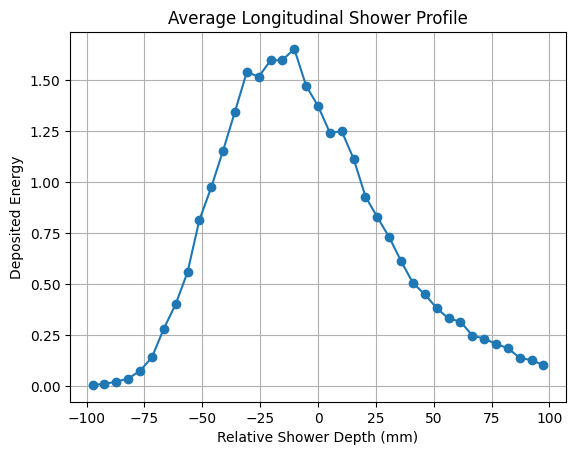

In [1]:
import numpy as np
import matplotlib.pyplot as plt    ####corrrrrecttttt
data = np.load("point_cloud_dataset.npy", allow_pickle=True)

beam_dir = np.array([0,1,0])

depth_all = []
E_all = []

for event in data:

    pos = event[:,0:3]
    E = event[:,3]

    depth = pos @ beam_dir

    depth = depth - np.mean(depth)

    depth_all.extend(depth)
    E_all.extend(E)

depth_all = np.array(depth_all)
E_all = np.array(E_all)

bins = np.linspace(-100, 100, 40)

energy_per_layer, edges = np.histogram(depth_all, bins=bins, weights=E_all)

centers = 0.5*(edges[1:] + edges[:-1])

plt.plot(centers, energy_per_layer, marker='o')
print(len(depth_all))
plt.xlabel("Relative Shower Depth (mm)")
plt.ylabel("Deposited Energy")
plt.title("Average Longitudinal Shower Profile")
plt.grid(True)
plt.show()

Transverse Profile - Radial energy distribution along x-z axis(plane). A satisfactory graph must be highest near centre and then decreasing..

26.945189


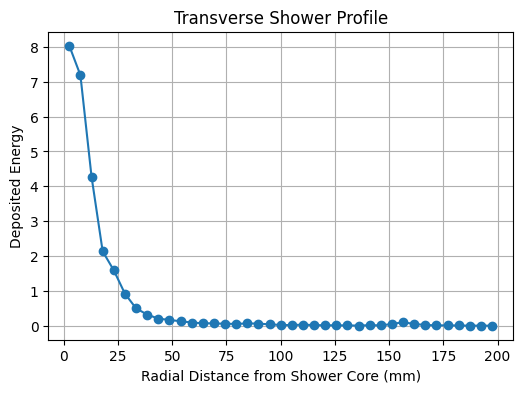

In [2]:
data = np.load("point_cloud_dataset.npy", allow_pickle=True)
data1 = [data[0]]


r_all = []
E_all = []

for event in data:

    x = event[:,0]
    z = event[:,2]
    E = event[:,3]

    # shower centroid
    x0 = np.mean(x)
    z0 = np.mean(z)

    # radial distance from shower core
    r = np.sqrt((x - x0)**2 + (z - z0)**2)

    r_all.extend(r)
    E_all.extend(E)

r_all = np.array(r_all)
E_all = np.array(E_all)

# restrict to useful region
max_radius = 200  # mm

bins = np.linspace(0, max_radius, 40)

energy_radial, edges = np.histogram(r_all, bins=bins, weights=E_all)

r_centers = 0.5 * (edges[1:] + edges[:-1])

plt.figure(figsize=(6,4))
plt.plot(r_centers, energy_radial, marker='o')

plt.xlabel("Radial Distance from Shower Core (mm)")
plt.ylabel("Deposited Energy")
plt.title("Transverse Shower Profile")
print(sum(E_all))
plt.grid(True)

plt.show()

Hit multiplicity and Centroid(of shower alon X and Z axes) -- 
Also shows radius having 90% of shower energy nearly at 30mm(specific case).

Total events: 100
37398


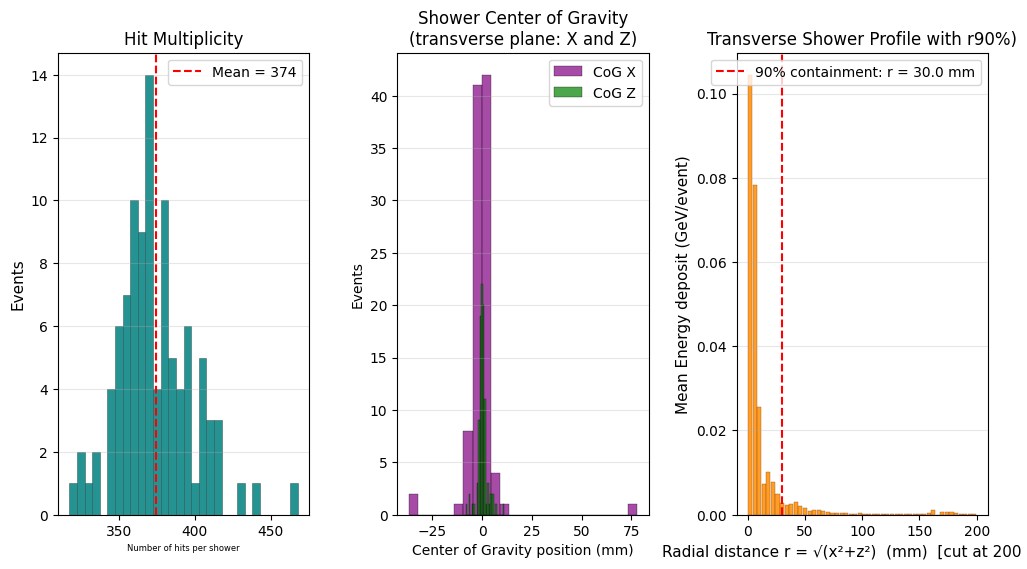

In [5]:
import matplotlib.gridspec as gridspec
data= np.load("point_cloud_dataset.npy", allow_pickle=True)

x_all =  [event[:,0] for event in data]
y_all =[event[:,1] for event in data]
z_all = z =[event[:,2] for event in data]
E_all = E = [event[:,3] for event in data]
    
    
n_events = len(x_all)
print(f"Total events: {n_events}")

x_flat = np.concatenate(x_all)
print(len(x_flat))
z_flat = np.concatenate(z_all)
E_flat = np.concatenate(E_all)

r_flat = np.sqrt(x_flat**2 + z_flat**2)

# Apply physics cut: EM shower core radius
r_cut = 200.0  # mm — well beyond any real EM shower
mask  = r_flat < r_cut
r_cut_flat = r_flat[mask]
E_cut_flat = E_flat[mask]

n_bins_trans = 50
r_bins   = np.linspace(0, r_cut, n_bins_trans + 1)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:])

E_per_ring, _ = np.histogram(r_cut_flat, bins=r_bins, weights=E_cut_flat)
E_per_ring_mean = E_per_ring / n_events

# 90% containment radius
E_cumsum = np.cumsum(E_per_ring_mean)
E_total_trans = E_cumsum[-1]
r_90_idx = np.searchsorted(E_cumsum, 0.9 * E_total_trans)
r_90 = r_centers[r_90_idx] if r_90_idx < len(r_centers) else None

n_hits = np.array([len(xi) for xi in x_all])

cog_x = np.array([np.average(xi, weights=ei) if np.sum(ei) > 0 else 0
                  for xi, ei in zip(x_all, E_all)])
cog_z = np.array([np.average(zi, weights=ei) if np.sum(ei) > 0 else 0
                  for zi, ei in zip(z_all, E_all)])

fig = plt.figure(figsize=(12, 6))


gs = gridspec.GridSpec(1, 3, figure=fig, hspace=0.42, wspace=0.35)

# --- Plot 2: Hit Multiplicity ---
ax2 = fig.add_subplot(gs[0, 0])
ax2.hist(n_hits, bins=30, color='teal', edgecolor='darkslategray',
         linewidth=0.4, alpha=0.85)
ax2.set_xlabel("Number of hits per shower", fontsize=6)
ax2.set_ylabel("Events", fontsize=11)
ax2.set_title("Hit Multiplicity")
ax2.axvline(np.mean(n_hits), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {np.mean(n_hits):.0f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# --- Plot 3: Transverse Profile--
ax3 = fig.add_subplot(gs[0,2])
ax3.bar(r_centers, E_per_ring_mean,
        width=(r_bins[1]-r_bins[0])*0.9,
        color='darkorange', edgecolor='saddlebrown', linewidth=0.3, alpha=0.85)
ax3.set_xlabel(f"Radial distance r = √(x²+z²)  (mm)  [cut at {r_cut:.0f} mm]", fontsize=11)
ax3.set_ylabel("Mean Energy deposit (GeV/event)", fontsize=11)
ax3.set_title("Transverse Shower Profile with r90%)")
ax3.grid(axis='y', alpha=0.3)
if r_90 is not None:
    ax3.axvline(r_90, color='red', linestyle='--', linewidth=1.5,
                label=f'90% containment: r = {r_90:.1f} mm')
    ax3.legend(fontsize=10)

# # --- Plot 4: Center of Gravity ---
ax4 = fig.add_subplot(gs[0,1])
ax4.hist(cog_x, bins=25, alpha=0.7, color='purple', label='CoG X', 
         edgecolor='black', lw=0.3)
ax4.hist(cog_z, bins=25, alpha=0.7, color='green', label='CoG Z',
         edgecolor='black', lw=0.3)
ax4.set_xlabel("Center of Gravity position (mm)")
ax4.set_ylabel("Events")
ax4.set_title("Shower Center of Gravity\n(transverse plane: X and Z)", )
ax4.legend()
ax4.grid(axis='y', alpha=0.3)
plt.show()

OPTIMIZATION Strategies -

I have tested and propose these initial steps before working on larger dataset, methods and pileline should remain same but must be scaled..

1. Filtering - May be done on the basis of Threshold_filter(individual hit energy) or K highest energy points..For simplicity and physical correctness, I've performed Threshold filtering here..

For filtering we took the brute-force approach to find the threshold energy in magnitudes of order 1e-(n), while minimising the Energy loss from original shower captured energy over total hits..()

 final points reduced to 31982 from 
 Energy: best tradeoff is with to 26.71 from 26.95 GeV with percentage 99.12
0.9912164


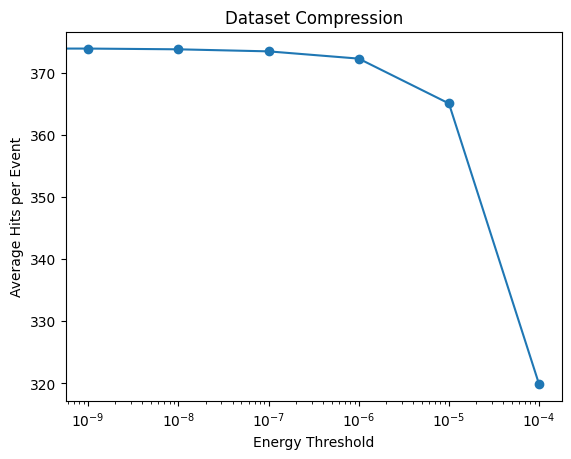

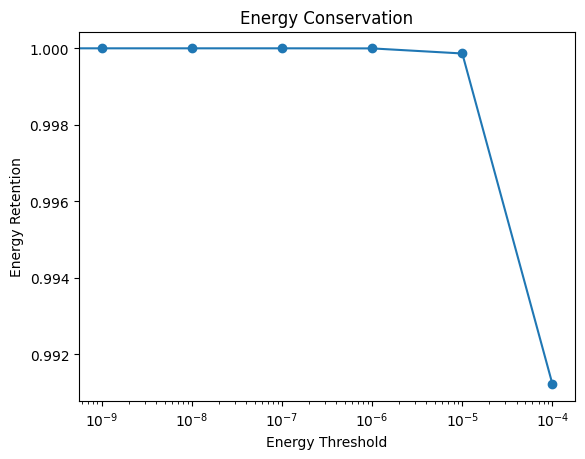

In [ ]:
data = np.load("point_cloud_dataset.npy", allow_pickle=True)

thresholds = [0,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4] ## This will be replaced with better approaches

avg_hits = []
energy_ratios = []

for t in thresholds:

    hits = []
    energy_before = []
    energy_after = []

    for event in data:

        E = event[:,3]

        energy_before.append(np.sum(E))

        filtered = event[E > t]

        hits.append(len(filtered))
        energy_after.append(np.sum(filtered[:,3]))

    avg_hits.append(np.mean(hits))
    energy_ratios.append(np.sum(energy_after)/np.sum(energy_before))

plt.plot(thresholds, avg_hits, marker="o")
print(f" final points reduced to {sum(hits)} from 37398 in the highest threshold filter" )
print(f" Energy: best tradeoff is with to {sum(energy_after):.2f} from {sum(energy_before):.2f} GeV with {(sum(energy_after)/sum(energy_before))*100:.2f} % energy conserved" )
# print(sum(energy_after)/sum(energy_before))
plt.xlabel("Energy Threshold")
plt.ylabel("Average Hits per Event")
plt.title("Dataset Compression")

plt.xscale("log")
plt.show()

plt.plot(thresholds, energy_ratios, marker="o")

plt.xlabel("Energy Threshold")
plt.ylabel("Energy Retention")
plt.title("Energy Conservation")

plt.xscale("log")
plt.show()

Longitudnal Shower Profile, should be preserved during any point reduction algorithm.

After selecting threshold as 1e-4 as energy is still~99% of the original, These graphs are plotted to show overlap

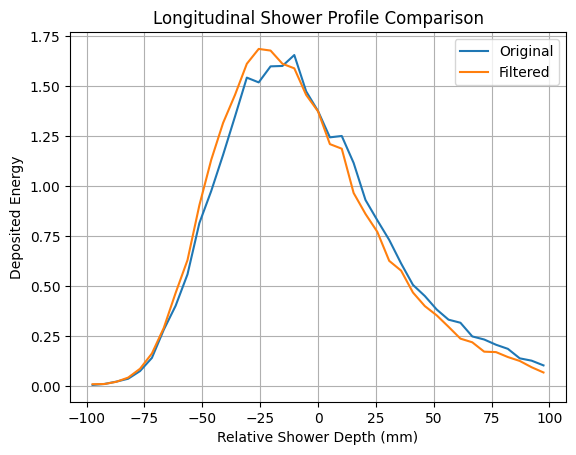

In [25]:
import numpy as np     # __________________________________------------->>Validationnnn
import matplotlib.pyplot as plt

data = np.load("point_cloud_dataset.npy", allow_pickle=True)

threshold = 1e-4

depth_orig = []
E_orig = []

depth_filt = []
E_filt = []

beam_dir = np.array([0,1,0])

for event in data:

    pos = event[:,0:3]
    E = event[:,3]

    depth = pos @ beam_dir
    depth = depth - np.mean(depth)

    depth_orig.extend(depth)
    E_orig.extend(E)

    mask = E > threshold
    pos_f = pos[mask]
    E_f = E[mask]

    depth_f = pos_f @ beam_dir
    depth_f = depth_f - np.mean(depth_f)

    depth_filt.extend(depth_f)
    E_filt.extend(E_f)

bins = np.linspace(-100,100,40)

E1,_ = np.histogram(depth_orig,bins=bins,weights=E_orig)
E2,_ = np.histogram(depth_filt,bins=bins,weights=E_filt)

centers = 0.5*(bins[1:]+bins[:-1])

plt.plot(centers,E1,label="Original")
plt.plot(centers,E2,label="Filtered")

plt.xlabel("Relative Shower Depth (mm)")
plt.ylabel("Deposited Energy")
plt.title("Longitudinal Shower Profile Comparison")

plt.legend()
plt.grid(True)
plt.show()

Transverse Shower Profile, should be preserved during any point reduction algorithm.

In [ ]:
r_orig = []
E_orig = []

r_filt = []
E_filt = []

for event in data:

    x = event[:,0]
    z = event[:,2]
    E = event[:,3]

    r = np.sqrt(x**2 + z**2)

    r_orig.extend(r)
    E_orig.extend(E)

    mask = E > threshold

    x_f = x[mask]
    z_f = z[mask]
    E_f = E[mask]

    r_f = np.sqrt(x_f**2 + z_f**2)

    r_filt.extend(r_f)
    E_filt.extend(E_f)

bins = np.linspace(0,200,40)

E1,_ = np.histogram(r_orig,bins=bins,weights=E_orig)
E2,_ = np.histogram(r_filt,bins=bins,weights=E_filt)

centers = 0.5*(bins[1:]+bins[:-1])

plt.plot(centers,E1,label="Original")
plt.plot(centers,E2,label="Filtered")

plt.xlabel("Radial Distance (mm)")
plt.ylabel("Deposited Energy")
plt.title("Transverse Shower Profile Comparison")

plt.legend()
plt.grid(True)
plt.show()

Radial Energy Containment is an additional metric which might be chosen for validation...

In [ ]:
r_orig = []
E_orig = []

r_filt = []
E_filt = []

for event in data:

    x = event[:,0]
    z = event[:,2]
    E = event[:,3]

    r = np.sqrt(x**2 + z**2)

    r_orig.extend(r)
    E_orig.extend(E)

    mask = E > threshold

    x_f = x[mask]
    z_f = z[mask]
    E_f = E[mask]

    r_f = np.sqrt(x_f**2 + z_f**2)

    r_filt.extend(r_f)
    E_filt.extend(E_f)

r_orig = np.array(r_orig)
E_orig = np.array(E_orig)

r_filt = np.array(r_filt)
E_filt = np.array(E_filt)


# sort by radius
idx_o = np.argsort(r_orig)
idx_f = np.argsort(r_filt)

r_o = r_orig[idx_o]
E_o = E_orig[idx_o]

r_f = r_filt[idx_f]
E_f = E_filt[idx_f]


# cumulative energy
cum_o = np.cumsum(E_o)
cum_f = np.cumsum(E_f)

frac_o = cum_o / cum_o[-1]
frac_f = cum_f / cum_f[-1]


plt.plot(r_o, frac_o, label="Original")
plt.plot(r_f, frac_f, label="Filtered")

plt.xlabel("Radius from Shower Axis (mm)")
plt.ylabel("Energy Containment Fraction")
plt.title("Radial Energy Containment")

plt.legend()
plt.grid(True)

plt.show()

Here in the Pipeline, taking raw data again (initial hits)

NOTE***** To prevent mistakes at scale, from here only single events are taken(nearly 360hits) I understand that this might not provide smooth curves but is an easy approach to start...

1. Threshold Filter(will extend further just a dummy use case here)
2. Clustering(Basic Cubic Cell clustering was performed, altough applying DBSCAN for now did not had satisfactory results)
3. Introductory Boundary filtering is introduced 

In [ ]:
event = data[0]
import numpy as np
# from sklearn.cluster import DBSCAN



# 1. Energy Threshold Filter


def threshold_filter(event, threshold=1e-9):

    mask = event[:,3] > threshold
    return event[mask]


# 2. Spatial Clustering


def cluster_hits(event, cell_size=10):
    
    if len(event) == 0:
        return event

    x = event[:,0]
    y = event[:,1]
    z = event[:,2]
    E = event[:,3]

    # discretizing into cubic cells
    gx = np.floor(x / cell_size)
    gy = np.floor(y / cell_size)
    gz = np.floor(z / cell_size)

    grid_keys = np.stack((gx,gy,gz), axis=1)

    clusters = {}

    for i,key in enumerate(map(tuple,grid_keys)):
        if key not in clusters:
            clusters[key] = []
        clusters[key].append(i)

    clustered = []

    for key,indices in clusters.items():

        pts = event[indices]

        xyz = pts[:,:3]
        energy = pts[:,3]

        centroid = np.average(xyz, axis=0, weights=energy)

        total_E = np.sum(energy)

        clustered.append([centroid[0], centroid[1], centroid[2], total_E])

    return np.array(clustered)


# 3. Bounding Filter


def bounding_filter(event, r_max=100):

    if len(event) == 0:
        return event

    x = event[:,0]
    y = event[:,1]
    E = event[:,3]

    # energy-weighted shower center
    x0 = np.average(x, weights=E)
    y0 = np.average(y, weights=E)

    r = np.sqrt((x-x0)**2 + (y-y0)**2)

    mask = r < r_max

    return event[mask]


# 4. Full Pipeline


def optimize_event(event):

    print("\n--- Optimization pipeline ---")

    print("Original hits:", len(event))
    print("Original energy:", np.sum(event[:,3]))

    event = threshold_filter(event)

    print("After threshold:", len(event))

    event = cluster_hits(event)

    print("After clustering:", len(event))

    event = bounding_filter(event)

    print("After bounding filter:", len(event))
    print("Final energy:", np.sum(event[:,3]))

    return event
optimized_event = optimize_event(event)
print(len(optimized_event))
data2 = [optimized_event]


--- Optimization pipeline ---
Original hits: 359
Original energy: 0.27831745
After threshold: 359
After clustering: 208
After bounding filter: 202
Final energy: 0.27725995
202


Transverse Profile is plotted First and then Longitudnal Profile Shower Graph..

The graphs are plotted against optimised vs original data to validate observables even after significant point reduction..
The more the graphs overlap, better is the optimization

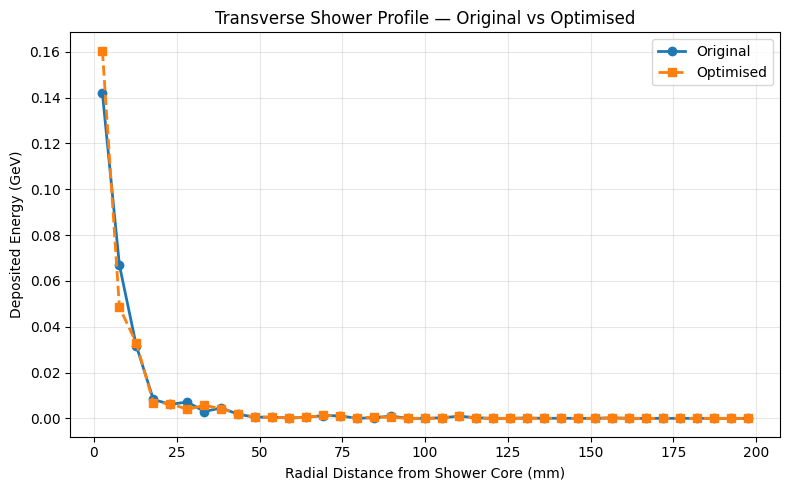

Total energy original:   0.2783 and 359 Hits
Total energy optimised:  0.2773 and 202 Hits
Points reduced:    157 hits (43.7% reduction)
Energy preserved:  99.6201%


In [ ]:
def get_transverse_profile(data1, max_radius=200, n_bins=40):
    r_all = []
    E_all = []

    for event in data1:
        x = event[:, 0]
        z = event[:, 2]
        E = event[:, 3]

        x0 = np.average(x, weights=E)
        z0 = np.average(z, weights=E)

        r = np.sqrt((x - x0)**2 + (z - z0)**2) #normalising

        r_all.extend(r)
        E_all.extend(E)

    r_all = np.array(r_all)
    E_all = np.array(E_all)

    bins = np.linspace(0, max_radius, n_bins)
    energy_radial, edges = np.histogram(r_all, bins=bins, weights=E_all)
    r_centers = 0.5 * (edges[1:] + edges[:-1])

    return r_centers, energy_radial


r_centers1, energy1 = get_transverse_profile(data1)  # original
r_centers2, energy2 = get_transverse_profile(data2)  # optimised


plt.figure(figsize=(8, 5))
plt.plot(r_centers1, energy1, marker='o', label="Original",  linewidth=2)
plt.plot(r_centers2, energy2, marker='s', label="Optimised", linewidth=2, linestyle='--')

plt.xlabel("Radial Distance from Shower Core (mm)")
plt.ylabel("Deposited Energy (GeV)")
plt.title("Transverse Shower Profile — Original vs Optimised")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Checkingg
print(f"Total energy original:   {sum(e[:,3].sum() for e in data1):.4f} and {len(data1[0])} Hits")
print(f"Total energy optimised:  {sum(e[:,3].sum() for e in data2):.4f} and {len(data2[0])} Hits")

print(f"Points reduced:    {len(data1[0])-len(data2[0])} hits ({(1 - len(data2[0])/len(data1[0]))*100:.1f}% reduction)")
print(f"Energy preserved:  {(sum(data2[0][:,3])/sum(data1[0][:,3]))*100:.4f}%")

In [ ]:
def get_longitudinal_profile(data, max_depth=200, n_bins=40):
    depth_all = []
    E_all = []

    for event in data:
        y = event[:, 1]
        E = event[:, 3]

        # normalising
        y_entry = y.min()
        depth   = y - y_entry

        depth_all.extend(depth)
        E_all.extend(E)

    depth_all = np.array(depth_all)
    E_all     = np.array(E_all)

    bins = np.linspace(0, max_depth, n_bins)
    energy_long, edges = np.histogram(depth_all, bins=bins, weights=E_all)
    d_centers = 0.5 * (edges[1:] + edges[:-1])

    return d_centers, energy_long



d_centers1, energy1 = get_longitudinal_profile(data1)
d_centers2, energy2 = get_longitudinal_profile(data2)

plt.figure(figsize=(8, 5))
plt.plot(d_centers1, energy1, marker='o', label="Original",  linewidth=2)
plt.plot(d_centers2, energy2, marker='s', label="Optimised", linewidth=2, linestyle='--')

plt.xlabel("Shower Depth  d = Y_hit - Y_entry  (mm)")
plt.ylabel("Deposited Energy (GeV)")
plt.title("Longitudinal Shower Profile — Original vs Optimised")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

""""r90 — the radius containing 90% of shower energy""""      
Total energy conservation is guaranteed by construction in cubic cell clustering — you sum all hit energies, so it's always 100%. It tells you nothing about whether the spatial distribution is preserved. 
r90 is the minimal additional check that validates spatial physics, not just energy accounting.

In [32]:
def r90(data):
    r_all, E_all = [], []
    for event in data:
        x, z, E = event[:,0], event[:,2], event[:,3]
        x0 = np.average(x, weights=E)
        z0 = np.average(z, weights=E)
        r = np.sqrt((x-x0)**2 + (z-z0)**2)
        r_all.extend(r)
        E_all.extend(E)
    r_all, E_all = np.array(r_all), np.array(E_all)
    sort_idx = np.argsort(r_all)
    cumE = np.cumsum(E_all[sort_idx])
    idx = np.searchsorted(cumE, 0.9 * cumE[-1])
    return r_all[sort_idx][idx]

print(f"r90 original:      {r90(data1):.1f} mm")
print(f"r90 clustered:     {r90(data2):.1f} mm")
print(f"r90 difference:    {abs(r90(data1)-r90(data2)):.1f} mm")

for cell_size in [5, 10, 15, 20, 25]:
    data_clustered = [cluster_hits(e, cell_size=cell_size) for e in data1]
    r90_val = r90(data_clustered)
    n_hits  = np.mean([len(e) for e in data_clustered])
    print(f"cell={cell_size}mm | hits={n_hits:.0f} | r90={r90_val:.1f}mm")

# Check energy preservation too at each cell size
for cell_size in [10, 15]:
    data_clustered = [cluster_hits(e, cell_size=cell_size) for e in data1]
    E_orig = np.mean([e[:,3].sum() for e in data1])
    E_clus = np.mean([e[:,3].sum() for e in data_clustered])
    n_orig = np.mean([len(e) for e in data1])
    n_clus = np.mean([len(e) for e in data_clustered])
    print(f"cell={cell_size}mm | "
          f"reduction={( 1-n_clus/n_orig)*100:.1f}% | "
          f"E preserved={E_clus/E_orig*100:.2f}% | "
          f"r90 shift={abs(r90(data1)-r90(data_clustered)):.1f}mm")

r90 original:      21.0 mm
r90 clustered:     21.1 mm
r90 difference:    0.2 mm
cell=5mm | hits=359 | r90=21.0mm
cell=10mm | hits=208 | r90=20.9mm
cell=15mm | hits=141 | r90=20.4mm
cell=20mm | hits=107 | r90=21.0mm
cell=25mm | hits=78 | r90=12.6mm
cell=10mm | reduction=42.1% | E preserved=100.00% | r90 shift=0.0mm
cell=15mm | reduction=60.7% | E preserved=100.00% | r90 shift=0.6mm


**IMPORTANT--At r90 = 20mm we realize radius shifted near only but thats not possible suggesting too much point reduction has lead to wrong physics logic
From the above output we conclude that if we increase cell dimension to more than 10mm, r90 shift triggers the spatial arrangement and shape of the shower, even tough there is 18% more absolute point reduction...

It is an important benchmark and further in learning I will try to use it more wisely..